In [1]:
import os
os.chdir("..")

In [2]:
from qwen_vl import *
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from plyfile import PlyData
from autoencoder.model_qwen import QwenAutoencoder

In [9]:
model, processor = get_patched_qwen(use_bnb_4bit=False)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [3]:
data_path = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080')
ims_path = data_path / 'images'
ae_path = data_path / 'autoencoder' / 'best_ckpt.pth'
inst_feat_path = data_path / 'qwen_instance_features_dim3'
patch_feat_path = data_path / 'qwen_patch_features_dim3'

In [4]:
ae = QwenAutoencoder(latent_dim=3).to("cuda")
ae.load_state_dict(torch.load(ae_path))
ae.eval()
pass

In [5]:
col_transform = lambda c: c/2+0.5

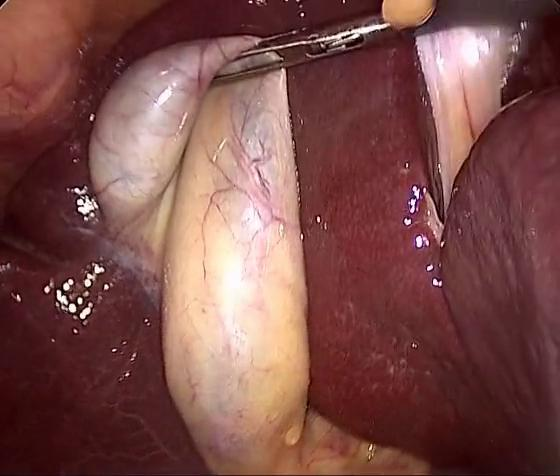

In [7]:
frame = 80
img = Image.open(ims_path / f'frame_{frame:06}.jpg')
img

In [14]:
ask_qwen_about_image(img, "This is a picture taken during a surgery. Which organs are present?", model, processor)

'The image shows the gallbladder being dissected from the liver. The liver is visible on the right side of the image, and the gallbladder is on the left.'

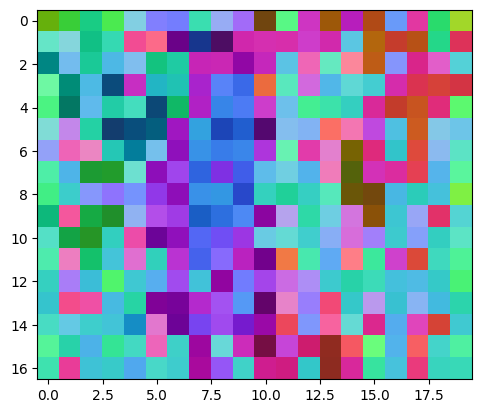

In [12]:
lf = qwen_encode_image(img, model, processor).float()
lf_latent = ae.encode(lf)
lf_2d = lf.reshape(img.height // 28, img.width // 28, -1)
lf_latent_2d = lf_latent.reshape(img.height // 28, img.width // 28, -1)
plt.imshow(col_transform(lf_latent_2d.detach().cpu()))
plt.show()

In [13]:
lf_latent_2d

tensor([[[-0.1943,  0.3806, -0.9041],
         [-0.5477,  0.6226, -0.5589],
         [-0.7962,  0.6036,  0.0415],
         ...,
         [ 0.7777, -0.5676,  0.2702],
         [-0.6743,  0.7230, -0.1505],
         [ 0.2737,  0.6887, -0.6714]],

        [[-0.2045,  0.7971,  0.5682],
         [ 0.0471,  0.6829,  0.7290],
         [-0.8589,  0.5101,  0.0445],
         ...,
         [ 0.4420, -0.3599, -0.8217],
         [-0.7176,  0.6918,  0.0807],
         [ 0.7388, -0.6038, -0.2994]],

        [[-0.9978,  0.0575,  0.0334],
         [-0.0975,  0.4819,  0.8708],
         [-0.7951,  0.5770,  0.1868],
         ...,
         [ 0.7045, -0.7046,  0.0853],
         [ 0.7753, -0.2553,  0.5777],
         [-0.3345,  0.6456,  0.6865]],

        ...,

        [[-0.4282,  0.7300,  0.5326],
         [-0.2109,  0.5779,  0.7884],
         [-0.5097,  0.6159,  0.6007],
         ...,
         [ 0.7582, -0.4552,  0.4669],
         [ 0.6743, -0.4701, -0.5695],
         [-0.4953,  0.5842,  0.6429]],

        [[

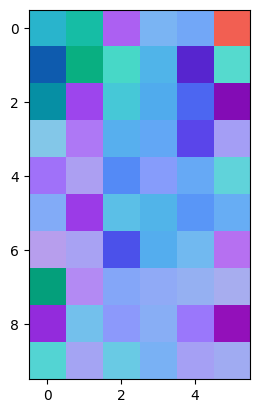

In [11]:
# gallbladder
lf_latent_cropped_2d = lf_latent_2d[3:13, 5:11]
lf_cropped = lf_2d[3:13, 5:11].reshape(-1, lf.shape[-1])
plt.imshow(col_transform(lf_latent_cropped_2d.detach().cpu()))
plt.show()

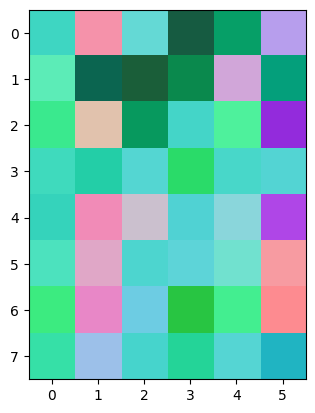

In [39]:
# liver
lf_latent_cropped_2d = lf_latent_2d[9:, :6]
lf_cropped = lf_2d[9:, :6].reshape(-1, lf.shape[-1])
plt.imshow(col_transform(lf_latent_cropped_2d.detach().cpu()))
plt.show()

In [ ]:
ask_qwen_about_image_features(qwen_encode_image(img, model, processor), "This is a picture taken during a surgery. Which organ is depicted?", model, processor)

'The image appears to be taken during a surgical procedure, likely involving the abdominal cavity. The visible structures include what looks like the liver (the large, reddish-brown organ on the right side of the image) and possibly parts of the intestines or other abdominal organs. The white, tube-like structure in the center could be part of the gastrointestinal tract, such as the duodenum or jejunum. The exact organs cannot be definitively identified without more context, but these are common structures found in the abdominal cavity during surgeries.'

In [13]:
ask_qwen_about_image_features(lf, "Which organ(s) are visible?", model, processor)

'The image shows the gallbladder, which is being dissected or removed. The surrounding structures include parts of the liver and possibly the duodenum, but the focus is on the gallbladder.'

In [ ]:
ask_qwen_about_image_features(ae.decode(lf_latent), "Which organ(s) are visible?", model, processor)

'The image shows the gallbladder, which is a small, pear-shaped organ located in the upper right quadrant of the abdomen. It is connected to the liver by the cystic duct and is part of the biliary system. The surrounding structures include parts of the liver and possibly the duodenum or other abdominal organs.'

In [12]:
ask_qwen_about_image_features(lf_cropped, "Which organ(s) are visible?", model, processor)

'The image shows the gallbladder, which is a small, pear-shaped organ located in the upper right quadrant of the abdomen. It is connected to the liver by the cystic duct and is responsible for storing and concentrating bile.'

### Testing the "gt"??

In [18]:
gt = np.load('output/cholecseg8k/video01/video01_00080/qwen_patch/video_lang/ours_10000/gt_npy/00060.npy')
gt = torch.tensor(gt)
gt = gt[::28, ::28]

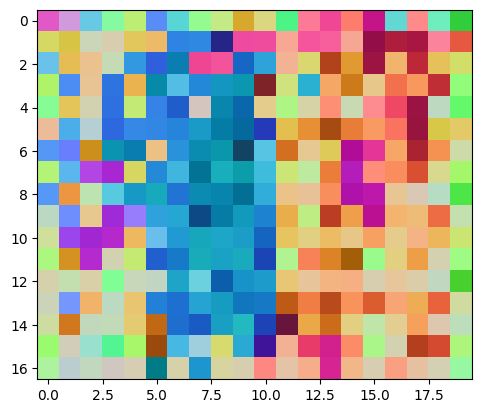

In [20]:
plt.imshow(col_transform(gt.numpy()))
plt.show()

In [28]:
ask_qwen_about_image_features(ae.decode(gt.flatten(end_dim=1).to('cuda')), "Which organ(s) are visible?", model, processor)

'The image shows the liver and possibly part of the stomach or duodenum. The liver is clearly visible with its characteristic texture and coloration. The surrounding structures suggest the presence of other abdominal organs, but the exact identification of each structure requires more context or additional images.'